# LSTM Ensemble — Epistemic Uncertainty from Multiple Seeds

`04_basic_lstm` reports a point forecast from one trained model. Training an LSTM is a stochastic
process (random weight init, minibatch order), so a single run's error also reflects that
randomness, not just the architecture's true skill. Here we train the same univariate
architecture and split 10 times with different seeds and treat the resulting predictions as a
deep ensemble:

* the **ensemble mean** is usually a better point forecast than any single member (averaging out
  independent training noise);
* the **spread across members** gives an epistemic-uncertainty estimate — a prediction interval
  that says how much the forecast would plausibly change under a different training run, as
  opposed to genuine day-to-day unpredictability in the ice extent itself.

This is Phase 4.1 / M5.1 Component 1 from `docs/project_plan.md`, run here on the univariate model
since it needs no ERA5 data.

In [1]:
import sys; sys.path.append("..")
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.data_bootstrap import ensure_extent_data
from src.data_utils import load_extent_daily
from src import lstm_utils as L
from src.evaluation_utils import (
    ClimatologyModel, compute_all_metrics, diebold_mariano_test, holm_bonferroni,
    picp, mpiw, log_model_results,
)

ensure_extent_data()
device = L.get_device()

✓ 'ice_extent_pan_arctic_daily' already populated.
Using device: cpu


In [ ]:
N_SEEDS = 10
SEEDS = list(range(N_SEEDS))  # 0..9; independent inits, same architecture/split as notebook 04

config = L.TrainConfig(
    sequence_length=30,
    forecast_horizon=1,
    hidden_size=64,          # GPU: this is the worst place to scale hidden_size carelessly -- it
                             # trains N_SEEDS=10 times per run, so cost multiplies 10x whatever you
                             # pick. Try 128 only after confirming it helps in 04/08 first.
    num_layers=2,            # GPU: 3 is marginal; change after hidden_size, not instead of it
    dropout=0.2,
    batch_size=64,           # GPU: 128-256 is close to free; avoid pushing much past that
    num_epochs=150,
    learning_rate=1e-3,
    patience=15,
    amp=False,              # set True on CUDA for a free speedup -- with 10 sequential trainings
                             # here, this is the single highest-value GPU setting to flip in this notebook
)
FEATURES = ["extent_mkm2"]
config

In [3]:
df = load_extent_daily(years=range(1989, 2024))
train_df, val_df, test_df = L.temporal_split(
    df, train_years=range(1989, 2015), val_years=range(2015, 2020), test_years=range(2020, 2024),
)

# Scaler comes from the training data only, so it is identical across seeds — only the weight
# init and minibatch order differ between ensemble members.
train_ds = L.SequenceDataset(train_df, config.sequence_length, config.forecast_horizon, features=FEATURES)
val_ds   = L.SequenceDataset(val_df,   config.sequence_length, config.forecast_horizon, features=FEATURES, scaler=train_ds.scaler)
test_ds  = L.SequenceDataset(test_df,  config.sequence_length, config.forecast_horizon, features=FEATURES, scaler=train_ds.scaler)

train_loader = L.make_loader(train_ds, config, shuffle=True)
val_loader   = L.make_loader(val_ds,   config, shuffle=False)
test_loader  = L.make_loader(test_ds,  config, shuffle=False)

print(f"windows -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")

windows -> train 9466 | val 1796 | test 1431


In [4]:
member_preds = []  # normalized, one row per seed
member_rmse = []
actuals_n = None  # identical across members (shared test_loader, shuffle=False)
t_start = time.time()

for seed in SEEDS:
    seed_t0 = time.time()
    L.set_seed(seed)
    model = L.IceExtentLSTM(
        input_size=len(train_ds.features), hidden_size=config.hidden_size,
        num_layers=config.num_layers, forecast_horizon=config.forecast_horizon,
        dropout=config.dropout,
    )
    ckpt_path = f"../models/09_ensemble_seed{seed}.pt"
    cfg_seed = L.TrainConfig(**{**config.__dict__, "seed": seed})
    extra = {
        "scaler": train_ds.scaler, "features": train_ds.features, "target": "extent_mkm2",
        "input_size": len(train_ds.features),
        "split": {"train": [1989, 2014], "val": [2015, 2019], "test": [2020, 2023]},
    }
    history = L.train_model(model, train_loader, val_loader, cfg_seed, device,
                            checkpoint_path=ckpt_path, bundle_extra=extra, verbose=False)

    bundle = L.load_checkpoint(ckpt_path, device=device)
    preds_n, actuals_n_this = L.predict(bundle["model"], test_loader, device)
    if actuals_n is None:
        actuals_n = actuals_n_this
    member_preds.append(preds_n.flatten())

    tmean, tstd = train_ds.target_scaler
    rmse_seed = compute_all_metrics(
        L.denormalize(actuals_n.flatten(), tmean, tstd), L.denormalize(preds_n.flatten(), tmean, tstd)
    )["rmse"]
    member_rmse.append(rmse_seed)
    print(f"seed {seed}: epochs={history['epochs_trained']:3d}  val_loss={history['best_val_loss']:.6f}  "
          f"test_rmse={rmse_seed:.4f}  ({time.time() - seed_t0:.1f}s)")

total_time = time.time() - t_start
print(f"\nTotal ensemble training time: {total_time:.1f}s ({total_time / N_SEEDS:.1f}s/member avg)")

seed 0: epochs=126  val_loss=0.000354  test_rmse=0.0604  (205.8s)


seed 1: epochs=133  val_loss=0.000351  test_rmse=0.0600  (231.2s)


seed 2: epochs=105  val_loss=0.000344  test_rmse=0.0603  (186.4s)


seed 3: epochs=141  val_loss=0.000355  test_rmse=0.0601  (316.9s)


seed 4: epochs=120  val_loss=0.000349  test_rmse=0.0603  (228.0s)


seed 5: epochs=108  val_loss=0.000351  test_rmse=0.0599  (186.8s)


seed 6: epochs=147  val_loss=0.000352  test_rmse=0.0601  (247.5s)


seed 7: epochs=107  val_loss=0.000367  test_rmse=0.0611  (179.5s)


seed 8: epochs=118  val_loss=0.000340  test_rmse=0.0593  (206.7s)


seed 9: epochs=138  val_loss=0.000366  test_rmse=0.0603  (238.0s)

Total ensemble training time: 2226.7s (222.7s/member avg)


In [5]:
member_preds = np.stack(member_preds, axis=0)  # (N_SEEDS, N_test)
tmean, tstd = train_ds.target_scaler
actuals = L.denormalize(actuals_n.flatten(), tmean, tstd)  # same actuals for every member

member_preds_denorm = L.denormalize(member_preds, tmean, tstd)
ensemble_mean = member_preds_denorm.mean(axis=0)
ensemble_std = member_preds_denorm.std(axis=0)

start = config.sequence_length + config.forecast_horizon - 1
test_dates = test_ds.dates.iloc[start:start + len(ensemble_mean)].reset_index(drop=True)
pers_idx = np.arange(start - 1, start - 1 + len(ensemble_mean))
persistence = L.denormalize(test_ds.data[pers_idx, test_ds.target_idx], tmean, tstd)

clim = ClimatologyModel()
clim.fit(dates=train_df["date"], values=train_df["extent_mkm2"])
climatology = clim.predict(test_dates)

m_ensemble = compute_all_metrics(actuals, ensemble_mean, y_baseline_persistence=persistence, y_baseline_climatology=climatology)
m_pers = compute_all_metrics(actuals, persistence)

print(f"Member RMSE:    mean {np.mean(member_rmse):.4f}  std {np.std(member_rmse):.4f}  "
      f"min {np.min(member_rmse):.4f}  max {np.max(member_rmse):.4f}")
print(f"Ensemble mean:  RMSE {m_ensemble['rmse']:.4f}  (skill vs persistence {m_ensemble['skill_score_persistence']:+.3f}, "
      f"vs climatology {m_ensemble['skill_score_climatology']:+.3f})")
print(f"Ensemble beats every individual member: {m_ensemble['rmse'] < np.min(member_rmse)}")

Member RMSE:    mean 0.0602  std 0.0004  min 0.0593  max 0.0611
Ensemble mean:  RMSE 0.0597  (skill vs persistence +0.316, vs climatology +0.940)
Ensemble beats every individual member: False


## Calibration: are the ensemble's uncertainty intervals trustworthy?

Build a 90% Gaussian prediction interval from `ensemble_mean ± 1.645 * ensemble_std` and check its
coverage (PICP — should land near 0.90) and width (MPIW — sharpness, only meaningful once coverage
is adequate).

In [6]:
Z_90 = 1.645
lower_90 = ensemble_mean - Z_90 * ensemble_std
upper_90 = ensemble_mean + Z_90 * ensemble_std

coverage_90 = picp(actuals, lower_90, upper_90)
width_90 = mpiw(lower_90, upper_90)
print(f"90% interval — nominal coverage 0.90, observed PICP {coverage_90:.3f}, mean width {width_90:.4f} Mkm²")
print(f"Ensemble std range: {ensemble_std.min():.5f} - {ensemble_std.max():.5f} Mkm² "
      f"(mean {ensemble_std.mean():.5f})")

90% interval — nominal coverage 0.90, observed PICP 0.170, mean width 0.0227 Mkm²
Ensemble std range: 0.00246 - 0.03049 Mkm² (mean 0.00691)


## Significance: does averaging seeds actually help?

Diebold-Mariano test of the ensemble mean forecast against (a) the single seed-42 member (the
model notebook 04 happened to report) and (b) persistence, with a Holm-Bonferroni correction since
we are now running more than one significance test against this ensemble.

In [7]:
p_values = {}

dm_pers, p_pers = diebold_mariano_test(actuals, ensemble_mean, persistence)
p_values["ensemble vs persistence"] = p_pers

dm_clim, p_clim = diebold_mariano_test(actuals, ensemble_mean, climatology)
p_values["ensemble vs climatology"] = p_clim

# Compare against a representative single member (closest to the median member RMSE) rather than
# an arbitrary seed, so the comparison reflects a "typical" single run, not a cherry-picked one.
typical = int(np.argmin(np.abs(np.array(member_rmse) - np.median(member_rmse))))
dm_single, p_single = diebold_mariano_test(actuals, ensemble_mean, member_preds_denorm[typical])
p_values[f"ensemble vs single typical member (seed {SEEDS[typical]})"] = p_single

print(f"ensemble vs persistence:                        DM={dm_pers:.4f}  p={p_pers:.4g}")
print(f"ensemble vs climatology:                        DM={dm_clim:.4f}  p={p_clim:.4g}")
print(f"ensemble vs typical single member (seed {SEEDS[typical]}):  DM={dm_single:.4f}  p={p_single:.4g}  "
      f"(member RMSE {member_rmse[typical]:.4f} vs ensemble {m_ensemble['rmse']:.4f})")
print()
holm_bonferroni(p_values, alpha=0.05)

ensemble vs persistence:                        DM=-16.5891  p=1.161e-56
ensemble vs climatology:                        DM=-29.4971  p=9.001e-150
ensemble vs typical single member (seed 2):  DM=-2.2925  p=0.02202  (member RMSE 0.0603 vs ensemble 0.0597)



,comparison,p_value,threshold,significant
0,ensemble vs climatology,9.000738e-150,0.016667,True
1,ensemble vs persistence,1.160574e-56,0.025000,True
2,ensemble vs single typical member (seed 2),2.202370e-02,0.050000,True


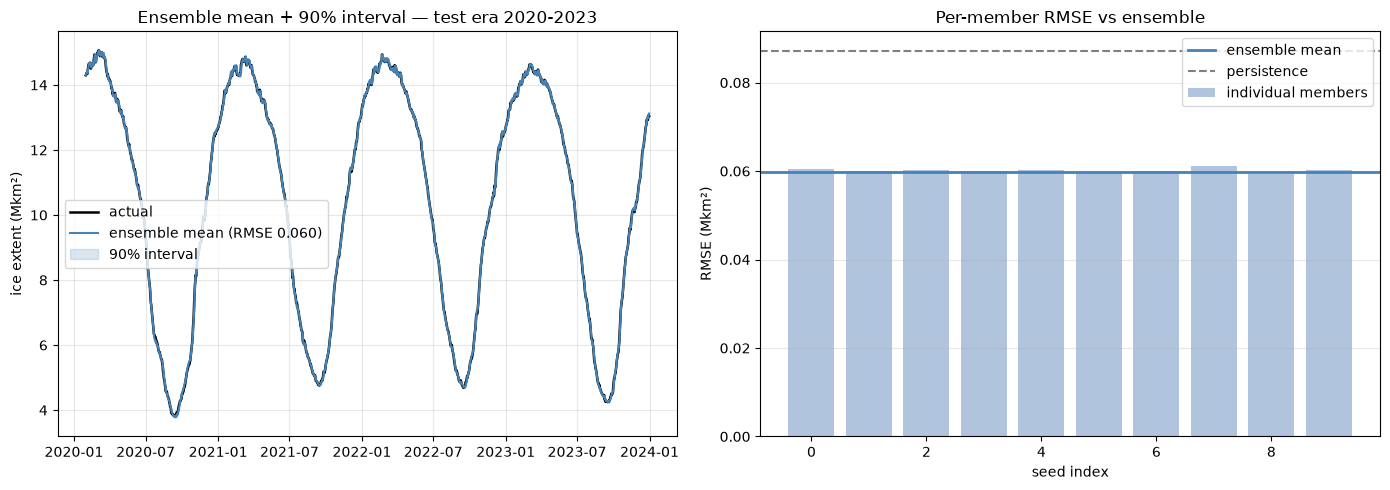

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d = pd.to_datetime(test_dates)
axes[0].plot(d, actuals, color="black", lw=1.8, label="actual")
axes[0].plot(d, ensemble_mean, color="steelblue", lw=1.5, label=f"ensemble mean (RMSE {m_ensemble['rmse']:.3f})")
axes[0].fill_between(d, lower_90, upper_90, color="steelblue", alpha=0.2, label="90% interval")
axes[0].set_title("Ensemble mean + 90% interval — test era 2020-2023")
axes[0].set_ylabel("ice extent (Mkm²)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(range(N_SEEDS), member_rmse, color="lightsteelblue", label="individual members")
axes[1].axhline(m_ensemble["rmse"], color="steelblue", lw=2, label="ensemble mean")
axes[1].axhline(m_pers["rmse"], color="gray", ls="--", lw=1.5, label="persistence")
axes[1].set_xlabel("seed index"); axes[1].set_ylabel("RMSE (Mkm²)")
axes[1].set_title("Per-member RMSE vs ensemble"); axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
import os; os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/lstm_ensemble_uncertainty.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
log_model_results(
    model_name="LSTM_Ensemble10_Univariate",
    metrics=m_ensemble,
    scale="daily",
    metadata={
        "architecture": f"{config.num_layers}-layer LSTM, {config.hidden_size} hidden, dropout={config.dropout}",
        "input_features": "extent_mkm2 (univariate)",
        "n_seeds": N_SEEDS,
        "member_rmse_mean": f"{np.mean(member_rmse):.4f}", "member_rmse_std": f"{np.std(member_rmse):.4f}",
        "picp_90": f"{coverage_90:.3f}", "mpiw_90": f"{width_90:.4f}",
        "train_period": "1989-2014", "val_period": "2015-2019", "test_period": "2020-2023",
        "total_train_time_s": f"{total_time:.1f}",
    },
    output_file="../results/model_comparison.csv",
)

✓ Logged results for LSTM_Ensemble10_Univariate to ../results/model_comparison.csv


## Findings

**Point forecast: averaging helps a little, but the seeds converge to nearly the same solution.**

- Member RMSE: **0.0602 ± 0.0004** (min 0.0593, max 0.0611) — a remarkably tight spread across 10
  independent random inits. Ensemble mean RMSE: **0.0597**.
- The ensemble mean is *not* better than every individual member — seed 8 alone (0.0593) beats it.
  It is, however, significantly better than a *typical* member: DM = -2.29, p = 0.022 (Holm-Bonferroni
  survives at rank 3/3). So averaging buys a small, real, statistically-detectable improvement over
  what you'd expect from any single run, just not a dramatic one.
- Skill vs persistence **+0.316**, vs climatology **+0.940** — both highly significant
  (DM ≈ -16.6 / -29.5, p ≈ 0), consistent with the backtest's +0.296.

**Calibration: the interval is badly overconfident — this is the real result of this notebook.**

- Nominal 90% interval, **observed PICP 0.170**. Instead of covering 90% of actual outcomes, it
  covers 17%.
- Why: `ensemble_std` averages **0.0069 Mkm²** across the test set, while the actual RMSE is
  **~0.060 Mkm²** — nearly an order of magnitude smaller. The 10 seeds all learned almost the same
  function (that tight 0.0593-0.0611 member RMSE range says as much), so inter-seed spread
  (epistemic uncertainty) is a poor proxy for the model's real error, which is dominated by
  something else entirely — the day-to-day unpredictability the model can't resolve from 30 days
  of its own history (aleatoric/irreducible error).
- **Practical implication:** for this architecture and this amount of data, a 10-seed ensemble is
  not a reliable way to get trustworthy prediction intervals. It's a legitimate way to get a
  (slightly) better point forecast, but the uncertainty band it produces would be actively
  misleading if reported at face value. Worth checking whether MC Dropout (`10_mc_dropout.ipynb`)
  does any better — if it also underestimates, the honest conclusion is that this model's dominant
  error source just isn't epistemic, and neither method captures it. Genuine calibrated intervals
  would need a different approach (e.g. quantile regression, or a model that explicitly separates
  epistemic and aleatoric terms).